<a href="https://colab.research.google.com/github/VrushankRamani/DSIP/blob/main/OPE2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sample Rate = 44100
Total Samples = 15040512

Processing IR 1
Impulse Response = [1 0 0 0 0 0 0 0 0 0]
Length = 10


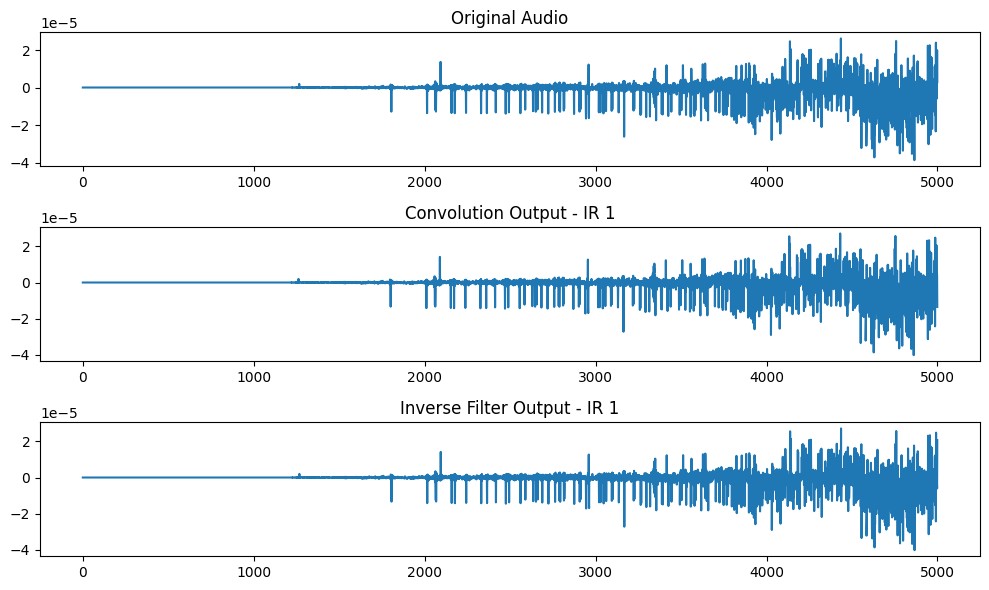


Processing IR 2
Impulse Response = [1.  0.5 0.  0.  0.  0.  0.  0.  0.  0. ]
Length = 10


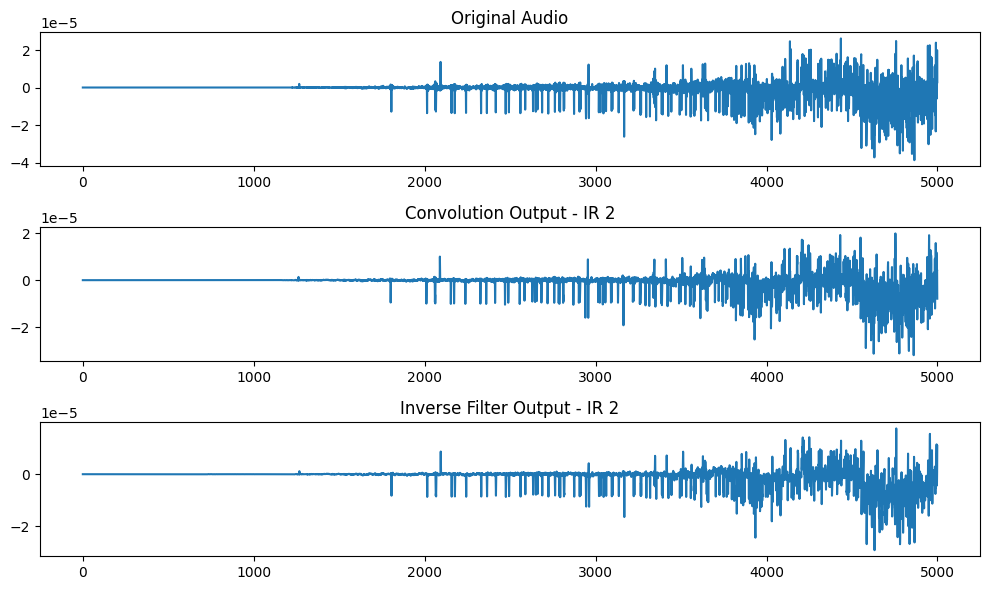


Processing IR 3
Impulse Response = [ 1 -1  0  0  0  0  0  0  0  0]
Length = 10


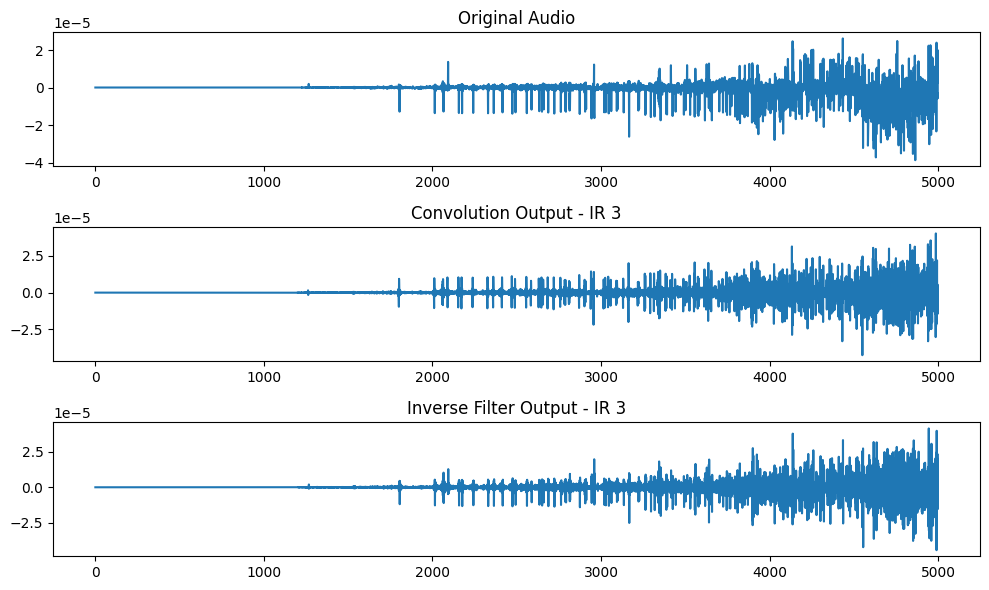


Processing IR 4
Impulse Response = [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Length = 10


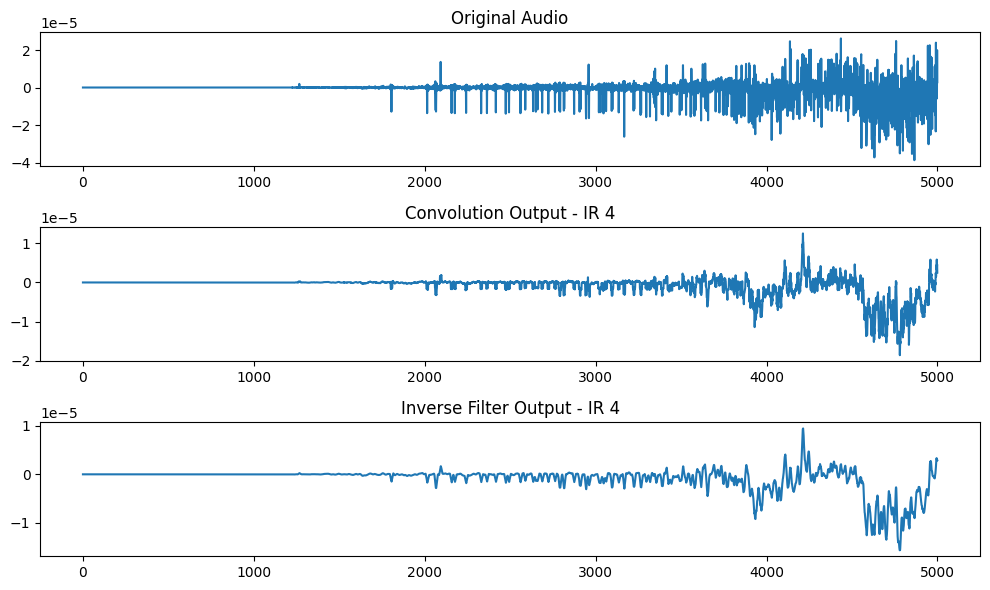


Part 1 Completed Successfully.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import fftconvolve

audio, sample_rate = sf.read("/content/Agar Tum Saath.mp3")

if len(audio.shape) == 2:
    audio = np.mean(audio, axis=1)

print("Sample Rate =", sample_rate)
print("Total Samples =", len(audio))

ir1 = np.array([
    1, 0, 0, 0, 0,
    0, 0, 0, 0, 0
])

ir2 = np.array([
    1, 0.5, 0, 0, 0,
    0, 0, 0, 0, 0
])

ir3 = np.array([
    1, -1, 0, 0, 0,
    0, 0, 0, 0, 0
])

ir4 = np.array([
    0.1, 0.1, 0.1, 0.1, 0.1,
    0.1, 0.1, 0.1, 0.1, 0.1
])

impulse_responses = [
    ir1,
    ir2,
    ir3,
    ir4
]

for i in range(len(impulse_responses)):

    print("\nProcessing IR", i + 1)

    kernel = impulse_responses[i]

    print("Impulse Response =", kernel)
    print("Length =", len(kernel))

    convoluted = fftconvolve(
        audio,
        kernel,
        mode="same"
    )

    max_value = np.max(np.abs(convoluted))

    if max_value != 0:
        convoluted = convoluted / max_value

    sf.write(
        "IR" + str(i + 1) + "_Convolution.wav",
        convoluted,
        sample_rate
    )

    inverse_kernel = kernel[::-1]

    restored = fftconvolve(
        convoluted,
        inverse_kernel,
        mode="same"
    )

    max_value = np.max(np.abs(restored))

    if max_value != 0:
        restored = restored / max_value

    sf.write(
        "IR" + str(i + 1) + "_Inverse.wav",
        restored,
        sample_rate
    )

    plot_samples = min(5000, len(audio))

    plt.figure(figsize=(10, 6))

    plt.subplot(3, 1, 1)
    plt.plot(audio[:plot_samples])
    plt.title("Original Audio")

    plt.subplot(3, 1, 2)
    plt.plot(convoluted[:plot_samples])
    plt.title("Convolution Output - IR " + str(i + 1))

    plt.subplot(3, 1, 3)
    plt.plot(restored[:plot_samples])
    plt.title("Inverse Filter Output - IR " + str(i + 1))

    plt.tight_layout()
    plt.show()

print("\nPart 1 Completed Successfully.")


Processing IR 5
Impulse Response = [1.  0.  0.  0.  0.  0.5 0.  0.  0.  0. ]
Length = 10


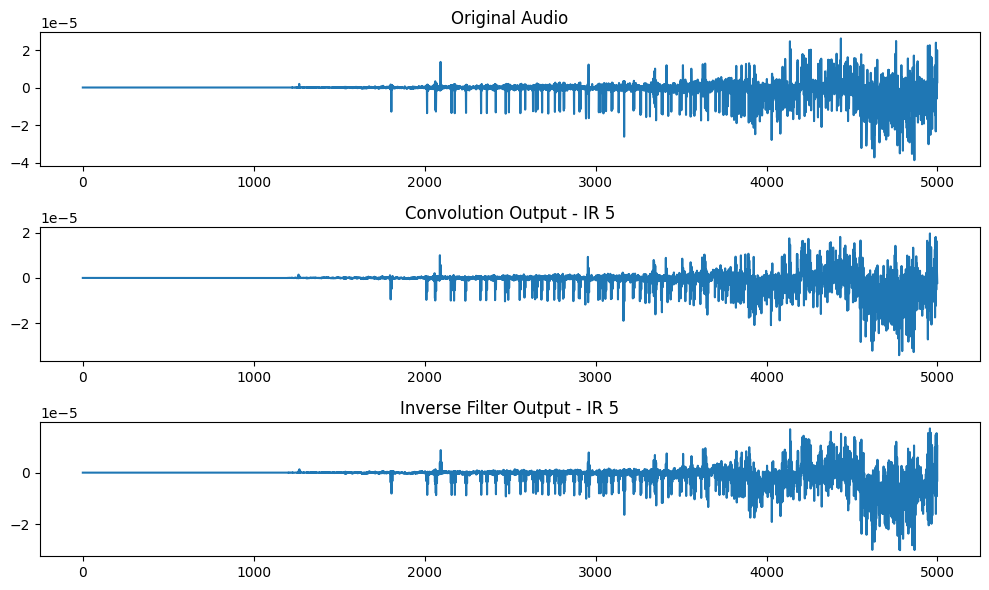


Processing IR 6
Impulse Response = [1.      0.5     0.25    0.125   0.0625  0.03125 0.      0.      0.
 0.     ]
Length = 10


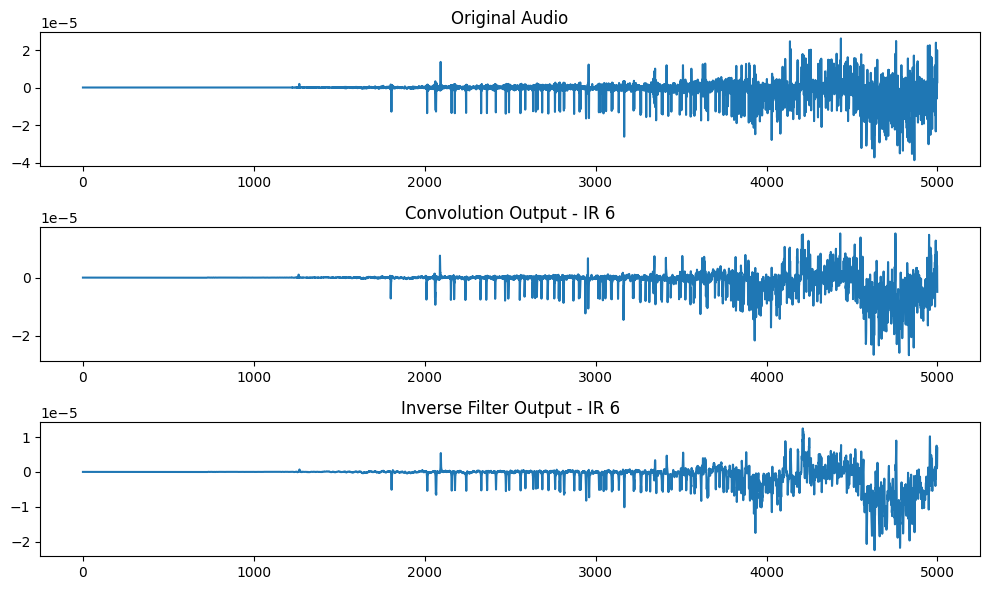


Processing IR 7
Impulse Response = [ 1.      -0.5      0.25    -0.125    0.0625  -0.03125  0.       0.
  0.       0.     ]
Length = 10


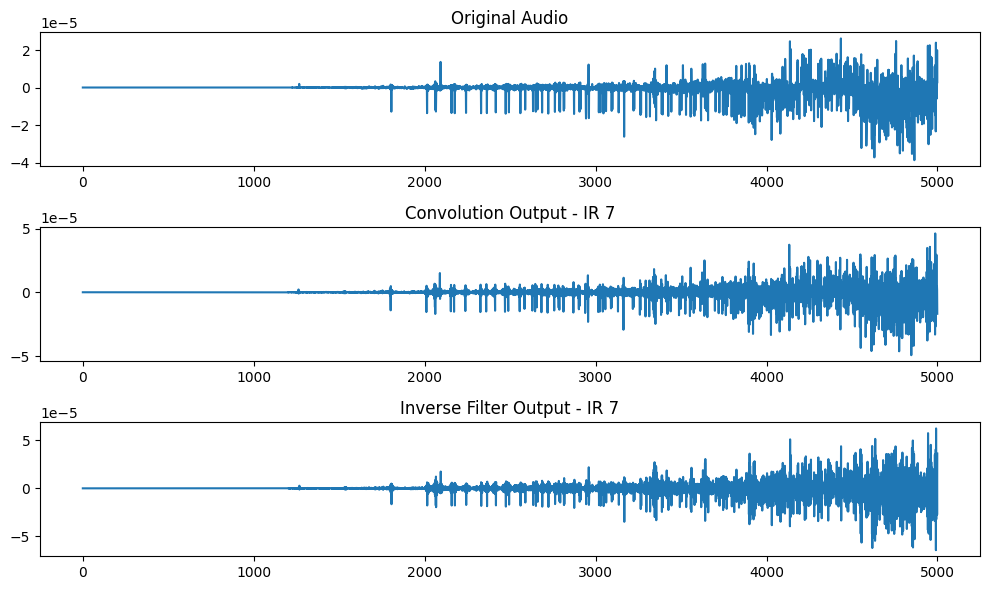


Part 2 Completed Successfully.


In [2]:
ir5 = np.array([
    1, 0, 0, 0, 0,
    0.5, 0, 0, 0, 0
])

ir6 = np.array([
    1, 0.5, 0.25, 0.125, 0.0625,
    0.03125, 0, 0, 0, 0
])

ir7 = np.array([
    1, -0.5, 0.25, -0.125, 0.0625,
    -0.03125, 0, 0, 0, 0
])

impulse_responses = [
    ir5,
    ir6,
    ir7
]

for i in range(len(impulse_responses)):

    ir_number = i + 5

    print("\nProcessing IR", ir_number)

    kernel = impulse_responses[i]

    print("Impulse Response =", kernel)
    print("Length =", len(kernel))

    convoluted = fftconvolve(
        audio,
        kernel,
        mode="same"
    )

    max_value = np.max(np.abs(convoluted))

    if max_value != 0:
        convoluted = convoluted / max_value

    sf.write(
        "IR" + str(ir_number) + "_Convolution.wav",
        convoluted,
        sample_rate
    )

    inverse_kernel = kernel[::-1]

    restored = fftconvolve(
        convoluted,
        inverse_kernel,
        mode="same"
    )

    max_value = np.max(np.abs(restored))

    if max_value != 0:
        restored = restored / max_value

    sf.write(
        "IR" + str(ir_number) + "_Inverse.wav",
        restored,
        sample_rate
    )

    plot_samples = min(5000, len(audio))

    plt.figure(figsize=(10, 6))

    plt.subplot(3, 1, 1)
    plt.plot(audio[:plot_samples])
    plt.title("Original Audio")

    plt.subplot(3, 1, 2)
    plt.plot(convoluted[:plot_samples])
    plt.title("Convolution Output - IR " + str(ir_number))

    plt.subplot(3, 1, 3)
    plt.plot(restored[:plot_samples])
    plt.title("Inverse Filter Output - IR " + str(ir_number))

    plt.tight_layout()
    plt.show()

print("\nPart 2 Completed Successfully.")